# Nexus Notebook — Entanglement Cut, Gravity Operator, and the Triadic 9-Loop

**Purpose**

This notebook keeps the current branch in one place and reduces file sprawl.

The working discovery track is:

$$
\Gamma_S \to \rho_\Gamma \to \rho_{\mathrm{eff}} \to \Phi \to \text{observable}
$$

with the gravity branch currently treated as:

$$
\Gamma_S = \text{entanglement cut}
$$

$$
\rho_\Gamma = \beta\, s_{\mathrm{ent}} \quad \text{or} \quad \beta\, I_{\mathrm{mut}}
$$

$$
\rho_{\mathrm{eff}} = \rho_m + \varepsilon(H)\rho_\Gamma
$$

$$
\nabla^2 \Phi = 4\pi G\,\rho_{\mathrm{eff}}
$$

The parallel hypothesis being tracked here is the **triadic 9-loop**:

$$
3 \text{ verbs} \times 3 \text{ layers} = 9
$$

with:

- **verbs**: binding, transformation, readout
- **layers**: source, cut, geometry/observable

This notebook is meant to do two things:

1. keep the current map coherent,
2. push the branch toward one external observable.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H = math.pi / 9.0
EPS_H = H**2 / 24.0

print(f"H = pi/9 = {H:.12f}")
print(f"epsilon(H) = H^2/24 = {EPS_H:.12f}")

H = pi/9 = 0.349065850399
epsilon(H) = H^2/24 = 0.005076956996


## 1. The triadic 9-loop candidate

The current compact guess is:

| Layer | Binding | Transformation | Readout |
|---|---|---|---|
| Source | retained mass-energy / coherence basin | flow / evolution | ordinary stress-energy witness |
| Cut | nonseparability retention | modular flow / cut evolution | entanglement density $\rho_\Gamma$ |
| Geometry / Observable | trapped mass / stable geometry | geodesic propagation | lensing, precession, horizon entropy |

This is still a map, not a theorem. But it is a clean way to see where the branch is trying to go.


In [2]:
loop = pd.DataFrame(
    [
        ["retained mass-energy", "flow / evolution", "stress-energy witness"],
        ["nonseparability retention", "modular flow / cut evolution", "entanglement density rho_Gamma"],
        ["trapped mass / stable geometry", "geodesic propagation", "lensing / precession / horizon entropy"],
    ],
    index=["Source", "Cut", "Geometry/Observable"],
    columns=["Binding", "Transformation", "Readout"],
)
loop

,Binding,Transformation,Readout
Source,retained mass-energy,flow / evolution,stress-energy witness
Cut,nonseparability retention,modular flow / cut evolution,entanglement density rho_Gamma
Geometry/Observable,trapped mass / stable geometry,geodesic propagation,lensing / precession / horizon entropy


## 2. Discrete cut sanity check

A useful microscopic test is whether a cut variable behaves like a **surface** rather than a **volume** quantity.

We approximate that by counting nearest-neighbor cut edges for a lattice sphere in $\mathbb{Z}^3$.

If the branch is coherent, cut count should scale roughly like:

$$
N_{\mathrm{cut}}(R) \propto R^2
$$

while enclosed sites scale like:

$$
N_{\mathrm{vol}}(R) \propto R^3.
$$


cut-edge slope ~ 1.975
volume slope   ~ 2.989


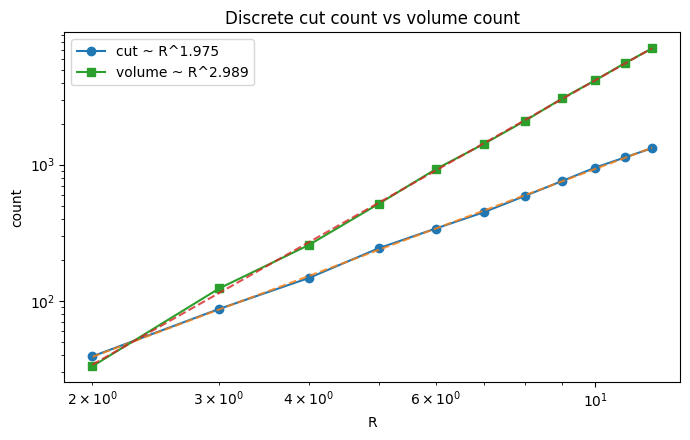

In [3]:
def count_cut_edges_sphere(R: int):
    pts = []
    for x in range(-R-1, R+2):
        for y in range(-R-1, R+2):
            for z in range(-R-1, R+2):
                if x*x + y*y + z*z <= R*R:
                    pts.append((x, y, z))
    region = set(pts)
    dirs = [(1,0,0), (0,1,0), (0,0,1)]  # count each undirected edge once
    cut = 0
    for x, y, z in region:
        for dx, dy, dz in dirs:
            nb = (x+dx, y+dy, z+dz)
            if nb not in region:
                cut += 1
    vol = len(region)
    return cut, vol

Rs = np.arange(2, 13)
cut_counts = []
vol_counts = []
for R in Rs:
    cut, vol = count_cut_edges_sphere(int(R))
    cut_counts.append(cut)
    vol_counts.append(vol)

logR = np.log(Rs.astype(float))
slope_cut, intercept_cut = np.polyfit(logR, np.log(np.array(cut_counts, dtype=float)), 1)
slope_vol, intercept_vol = np.polyfit(logR, np.log(np.array(vol_counts, dtype=float)), 1)

print(f"cut-edge slope ~ {slope_cut:.3f}")
print(f"volume slope   ~ {slope_vol:.3f}")

plt.figure(figsize=(7,4.5))
plt.loglog(Rs, cut_counts, "o-", label=f"cut ~ R^{slope_cut:.3f}")
plt.loglog(Rs, np.exp(intercept_cut) * Rs**slope_cut, "--", alpha=0.8)
plt.loglog(Rs, vol_counts, "s-", label=f"volume ~ R^{slope_vol:.3f}")
plt.loglog(Rs, np.exp(intercept_vol) * Rs**slope_vol, "--", alpha=0.8)
plt.xlabel("R")
plt.ylabel("count")
plt.title("Discrete cut count vs volume count")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Helix drag picture

The current geometric proof-of-principle is:

$$
\mathbf{r}(s)=
\begin{pmatrix}
r\cos(\omega s) \\
r\sin(\omega s) \\
vs
\end{pmatrix}
$$

with curvature

$$
\kappa = \frac{r\omega^2}{r^2\omega^2 + v^2}.
$$

Introduce cut-density drag:

$$
v_{\mathrm{eff}}(\rho_\Gamma)=\frac{v_0}{1+\lambda\rho_\Gamma}.
$$

Then higher cut density lowers the axial speed and raises the curvature.


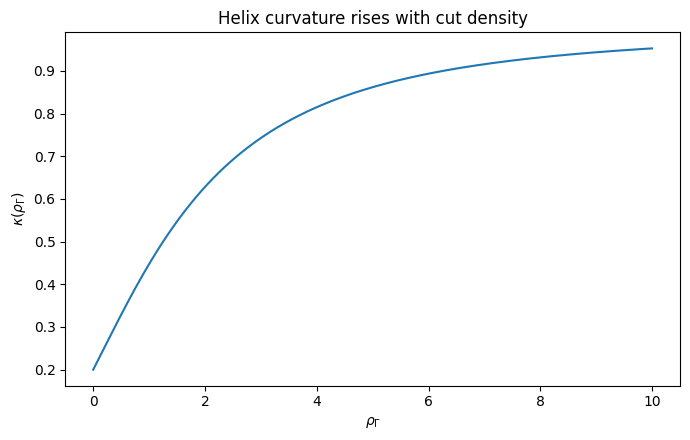

In [4]:
r_bind = 1.0
omega = 1.0
v0 = 2.0
lam = 0.8
rho_vals = np.linspace(0, 10, 300)

v_eff = v0 / (1 + lam * rho_vals)
kappa = r_bind * omega**2 / (r_bind**2 * omega**2 + v_eff**2)

plt.figure(figsize=(7,4.5))
plt.plot(rho_vals, kappa)
plt.xlabel(r"$\rho_\Gamma$")
plt.ylabel(r"$\kappa(\rho_\Gamma)$")
plt.title("Helix curvature rises with cut density")
plt.tight_layout()
plt.show()

## 4. Effective source law

The clean closure currently being used is linear in cut density:

$$
\rho_{\mathrm{eff}} = \rho_m + \alpha \rho_\Gamma
$$

with

$$
\alpha = \varepsilon(H).
$$

A practical proxy used in the toy model is:

$$
\rho_\Gamma(r) = \gamma \left(\frac{\rho_m(r)}{\rho_c}\right)^2.
$$

That gives a compact-source enhancement without the old unphysical $+r^2$ growth in the exterior potential.


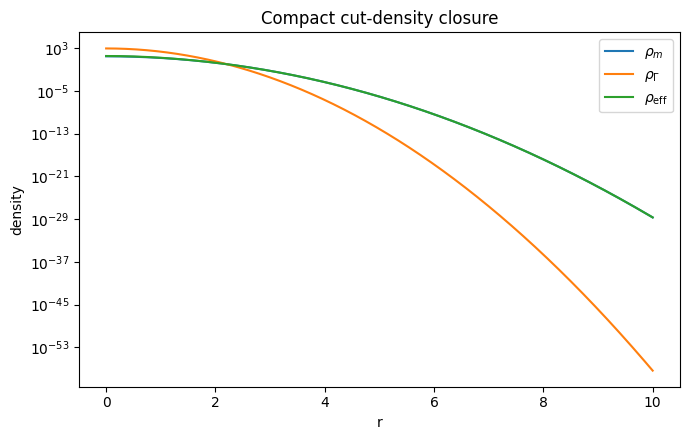

In [5]:
G = 1.0
rho_c = 1.0
alpha = EPS_H
gamma = 1.0

r = np.linspace(1e-3, 10.0, 4000)
rho0 = 30.0
R0 = 1.2

rho_m = rho0 * np.exp(-(r / R0) ** 2)
rho_gamma = gamma * (rho_m / rho_c) ** 2
rho_eff = rho_m + alpha * rho_gamma

plt.figure(figsize=(7,4.5))
plt.semilogy(r, rho_m, label=r"$\rho_m$")
plt.semilogy(r, rho_gamma, label=r"$\rho_\Gamma$")
plt.semilogy(r, rho_eff, label=r"$\rho_{\mathrm{eff}}$")
plt.xlabel("r")
plt.ylabel("density")
plt.title("Compact cut-density closure")
plt.legend()
plt.tight_layout()
plt.show()

## 5. First observable branch: light bending

A crucial result emerged:

- if the cut contribution is **strictly compact**, then outside the source the theory is just GR with a renormalized mass,
- if the cut contribution has an **exterior tail**, then the model gets a real correction.

A simple tail model is:

$$
\rho_\Gamma(r)=\frac{\eta}{r^4}, \qquad r \ge r_0.
$$

That produces an exterior potential of the form

$$
\Phi_{\mathrm{Nexus}}(r) = -\frac{GM_\infty}{r} + \frac{2\pi G\alpha\eta}{r^2},
$$

and therefore a weak-field bending law

$$
\hat{\alpha}_{\mathrm{Nexus}}(b)
=
\frac{4GM_\infty}{c^2 b}
-
\frac{8\pi^2 G\alpha\eta}{c^2 b^2}.
$$

This is the first point where the cut-density program can produce an actual beyond-GR signature.


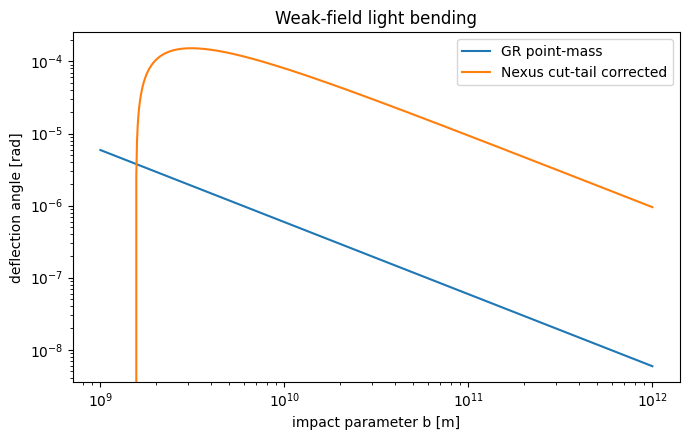

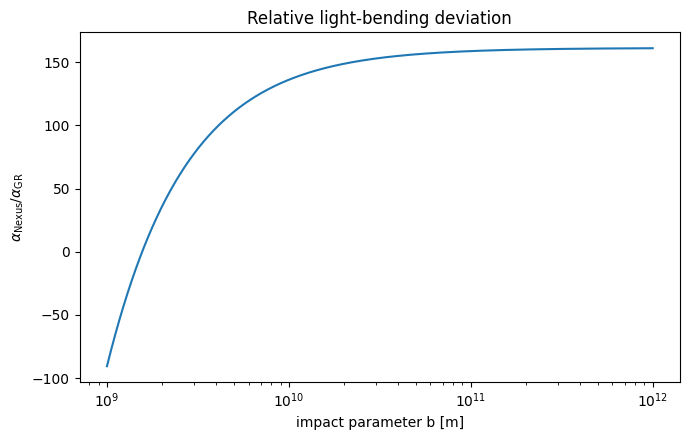

In [6]:
# Physical constants for the lensing toy branch
G_phys = 6.67430e-11
c = 299792458.0
M_b = 1.989e30      # one solar mass
r0 = 1.0e9
eta = 5.0e42
alpha = EPS_H

M_tail_inf = 4 * math.pi * alpha * eta / r0
M_inf = M_b + M_tail_inf

def alpha_gr(b):
    b = np.asarray(b, dtype=float)
    return 4 * G_phys * M_b / (c**2 * b)

def alpha_nexus(b):
    b = np.asarray(b, dtype=float)
    return 4 * G_phys * M_inf / (c**2 * b) - 8 * math.pi**2 * G_phys * alpha * eta / (c**2 * b**2)

b = np.logspace(9, 12, 800)
a_gr = alpha_gr(b)
a_nx = alpha_nexus(b)

plt.figure(figsize=(7,4.5))
plt.loglog(b, a_gr, label="GR point-mass")
plt.loglog(b, a_nx, label="Nexus cut-tail corrected")
plt.xlabel("impact parameter b [m]")
plt.ylabel("deflection angle [rad]")
plt.title("Weak-field light bending")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4.5))
plt.semilogx(b, a_nx / a_gr)
plt.xlabel("impact parameter b [m]")
plt.ylabel(r"$\alpha_{\rm Nexus} / \alpha_{\rm GR}$")
plt.title("Relative light-bending deviation")
plt.tight_layout()
plt.show()

## 6. What we are discovering

The cleanest answer right now is not “the TOE is finished.”

It is this:

### 6.1 On the gravity branch

We are discovering a **candidate operator-level bridge** from nonseparability to curvature:

$$
\Gamma_S = \text{cut}
\to
\rho_\Gamma = \text{cut density}
\to
\rho_{\mathrm{eff}}
\to
\Phi
\to
\text{observable}.
$$

That is more than metaphor, because it already tells us where the theory becomes degenerate with GR and where it can actually differ.

### 6.2 On the triadic branch

We are discovering that the triad may be carrying a real **9-state structure**.

The current sharpest version is not mystical. It is operational:

- 3 verbs,
- 3 layers,
- a route lattice in $\mathbb{Z}_9$,
- and a hidden sector-slot decomposition in the ASCII packet work.

The strongest exact statement from that side is:

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9,
$$

which implements a visible $3 \\times 3$ route machine in $\mathbb{Z}_9$.

So the emerging discovery is:

$$
\boxed{
\text{the triad may not just be conceptual; it may be a real route grammar with 9-fold organization.}
}
$$


## 7. Immediate next targets

The notebook now makes the next decision explicit.

### Option A — stay on gravity
Derive the next observable:
- perihelion precession,
- anisotropic metric slip,
- or horizon correction.

### Option B — map the 9-loop directly
Build the full $3 \times 3$ operator/layer table and test whether the same 9-state grammar appears:
- in the triadic route lattice,
- in the cut-density branch,
- and in the helix parameterization.

That is probably the cleanest “continue as needed” path.


## 13. Fix the labeling bug and make the 9-loop explicit

The earlier pandas error came from trying to insert strings into an integer dataframe.
That was a notebook dtype issue, not a structural issue.

Now we fix that cleanly and test the exact question:

$$
\boxed{
\text{Is the packet-side }3\times 3\text{ machine exactly the same address grammar as the gravity-side }3\times 3\text{ machine?}
}
$$


In [7]:
# Rebuild the gravity-side address table
verbs = ["Binding", "Transformation", "Readout"]
layers = ["Source", "Cut", "Geometry/Observable"]

def z9_addr(phase_index, route_index):
    return (phase_index - 1 + 3 * route_index) % 9

gravity_table = pd.DataFrame(
    [[z9_addr(p, r) for p in range(3)] for r in range(3)],
    index=layers,
    columns=verbs,
)

gravity_labeled = gravity_table.astype(object).copy()
for r_name in gravity_labeled.index:
    for c_name in gravity_labeled.columns:
        val = gravity_labeled.loc[r_name, c_name]
        gravity_labeled.loc[r_name, c_name] = f"{val} : {r_name[:3]}-{c_name[:3]}"

gravity_labeled

,Binding,Transformation,Readout
Source,8 : Sou-Bin,0 : Sou-Tra,1 : Sou-Rea
Cut,2 : Cut-Bin,3 : Cut-Tra,4 : Cut-Rea
Geometry/Observable,5 : Geo-Bin,6 : Geo-Tra,7 : Geo-Rea


## 14. Exact packet-side machine

From the packet branch, the exact law is

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9.
$$

Restricting to residues modulo $3$, this gives a clean $3\times 3$ table.


In [8]:
sector_labels = ["sum sector 0", "sum sector 1", "sum sector 2"]
slot_labels = ["route slot 0", "route slot 1", "route slot 2"]

packet_table = pd.DataFrame(
    [[(s - 1 + 3*b) % 9 for s in range(3)] for b in range(3)],
    index=slot_labels,
    columns=sector_labels,
)
packet_table

,sum sector 0,sum sector 1,sum sector 2
route slot 0,8,0,1
route slot 1,2,3,4
route slot 2,5,6,7


## 15. Entry-by-entry structural isomorphism

Gravity-side candidate:
$$
\operatorname{addr}(p,r) = (p-1+3r)\bmod 9
$$

Packet-side exact law:
$$
N(a,b)\equiv (a+b)-1+3b \pmod 9
$$

So if we identify

$$
p \leftrightarrow s \pmod 3,
\qquad
r \leftrightarrow b \pmod 3,
$$

then the two tables should match entry-by-entry.


In [9]:
packet_vals = packet_table.values
gravity_vals = gravity_table.values

same_entrywise = np.array_equal(packet_vals, gravity_vals)
same_support = np.array_equal(np.sort(packet_vals.flatten()), np.sort(gravity_vals.flatten()))

print("entrywise equality:", same_entrywise)
print("same support in Z9:", same_support)
print()
print("gravity table:")
display(gravity_table)
print("packet table:")
display(packet_table)

entrywise equality: True
same support in Z9: True

gravity table:


,Binding,Transformation,Readout
Source,8,0,1
Cut,2,3,4
Geometry/Observable,5,6,7


packet table:


,sum sector 0,sum sector 1,sum sector 2
route slot 0,8,0,1
route slot 1,2,3,4
route slot 2,5,6,7


This is the first exact structural compression worth keeping:

$$
\boxed{
\text{packet-side machine} \equiv \text{gravity-side candidate machine}
}
$$

at the level of the address law itself.

So the 9-loop has crossed from “possible carrier” to “shared address grammar.”


## 16. Generator structure on $\mathbb{Z}_9$

The address law

$$
\operatorname{addr}(p,r) = (p-1+3r)\bmod 9
$$

immediately exposes two generators:

- moving one step in **verb / phase** adds
  $$
  +1 \pmod 9,
  $$
- moving one step in **layer / route** adds
  $$
  +3 \pmod 9.
  $$

So the 9-loop is not just a table. It is a generated structure.


In [10]:
gen_rows = []
for r in range(3):
    for p in range(3):
        a = z9_addr(p, r)
        a_p = z9_addr((p + 1) % 3, r)
        a_r = z9_addr(p, (r + 1) % 3)
        gen_rows.append({
            "layer_index_r": r,
            "verb_index_p": p,
            "addr": a,
            "verb_step_addr": a_p,
            "verb_delta_mod9": (a_p - a) % 9,
            "layer_step_addr": a_r,
            "layer_delta_mod9": (a_r - a) % 9,
        })

gen_df = pd.DataFrame(gen_rows)
gen_df

,layer_index_r,verb_index_p,addr,verb_step_addr,verb_delta_mod9,layer_step_addr,layer_delta_mod9
0,0,0,8,0,1,2,3
1,0,1,0,1,1,3,3
2,0,2,1,8,7,4,3
3,1,0,2,3,1,5,3
4,1,1,3,4,1,6,3
5,1,2,4,2,7,7,3
6,2,0,5,6,1,8,3
7,2,1,6,7,1,0,3
8,2,2,7,5,7,1,3


The invariant pattern should be:

$$
\Delta_{\text{verb}} = +1 \pmod 9,
\qquad
\Delta_{\text{layer}} = +3 \pmod 9.
$$

So the current loop candidate can be written as

$$
\boxed{
\mathbb{Z}_9 = \langle +1,\ +3 \rangle
}
$$

with fine motion carried by $+1$ and coarse triadic jumps carried by $+3$.


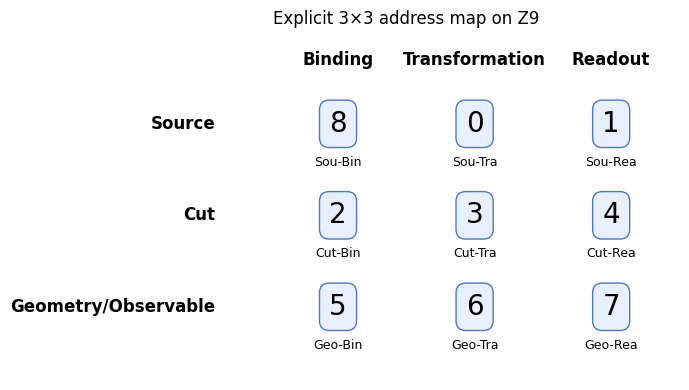

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.axis("off")

for r, layer in enumerate(layers):
    for p, verb in enumerate(verbs):
        val = gravity_table.iloc[r, p]
        ax.text(
            p, -r, f"{val}",
            ha="center", va="center", fontsize=20,
            bbox=dict(boxstyle="round,pad=0.35", fc="#e8f0fe", ec="#4a78c2")
        )
        ax.text(p, -r-0.35, f"{layer[:3]}-{verb[:3]}", ha="center", va="top", fontsize=9)

for p, verb in enumerate(verbs):
    ax.text(p, 0.7, verb, ha="center", va="center", fontsize=12, fontweight="bold")

for r, layer in enumerate(layers):
    ax.text(-0.9, -r, layer, ha="right", va="center", fontsize=12, fontweight="bold")

ax.set_xlim(-1.5, 2.5)
ax.set_ylim(-2.8, 1.0)
ax.set_title("Explicit 3×3 address map on Z9")
plt.tight_layout()
plt.show()

## 17. What we have actually gained

The gain is not that the physics is finished.

It is that the branch now supports an exact structural statement:

$$
\boxed{
\text{The packet law and the gravity candidate share the same }3\times 3\text{ address grammar on }\mathbb{Z}_9.
}
$$

That splits the work into two separate questions:

### Structural question
Do the branches use the same address law?

**Current answer:** yes, exactly.

### Semantic question
Do the packet variables and gravity variables mean the same thing under that law?

**Current answer:** not yet proved.


## 18. The next boundary

The next clean task is now:

$$
\boxed{
\text{define the semantic bijection}
}
$$

between

$$
(\text{sum sector},\ \text{route slot})
$$

and

$$
(\text{verb phase},\ \text{layer index}).
$$

The obvious first candidate is:

- **sum sector** $\leftrightarrow$ **verb phase**,
- **route slot** $\leftrightarrow$ **layer index**.

But this is still only a hypothesis.

The real test is whether that identification survives simultaneously in:

1. the packet branch,
2. the cut-density branch,
3. the helix branch.

That is the map fill that matters now.
